## A06b

In [1]:
# import pandas --- spreadsheet library
import pandas as pd

import numpy as np

# import matplotlib --- plotting library
import matplotlib.pyplot as plt

from plotting import make_overview, compare

In [2]:
%matplotlib inline

In [3]:
import os

fdir = '../../Data/Calibration Data/Agrifood/Clean data'

fpath = os.path.join(fdir,'Yield/KBL - 2006.csv')
dfo = pd.read_csv(fpath)

fpath = os.path.join(fdir, 'Weather/A06b.csv')
dfw = pd.read_csv(fpath, sep='\t', skiprows=3)

In [4]:
def harmonize_weather_file(fpath):

    with open(fpath, 'r') as f:
        text = f.read()
    
    lines = text.splitlines()
    
    lines[2] = lines[2].replace(' ','\t')
    lines[3] = lines[3].replace(' ','\t')
    
    fname, ext = os.path.splitext(fpath)
    
    nfname = fname + '-e'
    
    nfpath = nfname + ext
    
    text = '\n'.join(lines)
    
    with open(nfpath, 'w') as f:
        f.write(text)
    
    return nfpath

def compose_date(years, months=1, days=1, weeks=None, hours=None, minutes=None,
                 seconds=None, milliseconds=None, microseconds=None, nanoseconds=None):
    years = np.asarray(years) - 1970
    months = np.asarray(months) - 1
    days = np.asarray(days) - 1
    types = ('<M8[Y]', '<m8[M]', '<m8[D]', '<m8[W]', '<m8[h]',
             '<m8[m]', '<m8[s]', '<m8[ms]', '<m8[us]', '<m8[ns]')
    vals = (years, months, days, weeks, hours, minutes, seconds,
            milliseconds, microseconds, nanoseconds)
    return sum(np.asarray(v, dtype=t) for t, v in zip(types, vals)
               if v is not None)

In [5]:
nfpath = harmonize_weather_file(fpath)

In [6]:
dfw = pd.read_csv(nfpath, sep='\t', skiprows=2)
dfw = dfw.drop([0],axis=0)
dfw = dfw.astype('float')
dfw.index = compose_date(dfw['Year'], days=dfw['DOY'])
dfw = dfw.sort_index()
dfw = dfw.drop(['Year','DOY'], axis=1)

In [7]:
dfo = dfo.set_index(pd.to_datetime(dfo['Month']))

In [8]:
dfo = dfo.dropna(how='all')

In [12]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

# 1. Initialize the model
dt = 10

p = PalmField(year_of_planting=2003, month_of_planting=6, dt=dt)
p.soil.parameters['water_holding_capacity']['value'] = 450

# 2. Couple the solar radiation data:
dfw = dfw.resample('D').pad()
dfw = dfw.rolling(dt, center=True).mean()
dfw = dfw.fillna(method='pad')

p.weather.radiation_series = dfw['Solar']
p.weather.rainfall_series = dfw['Precip']
p.weather.humidity_series = dfw['RelHum']

nyears = 18

duration = nyears*365

df = p.run(duration=duration)

r**2:  0.006575348706622704
r**2:  0.884257872783783
r**2:  0.7102293662017253
Saving as: A06b.png


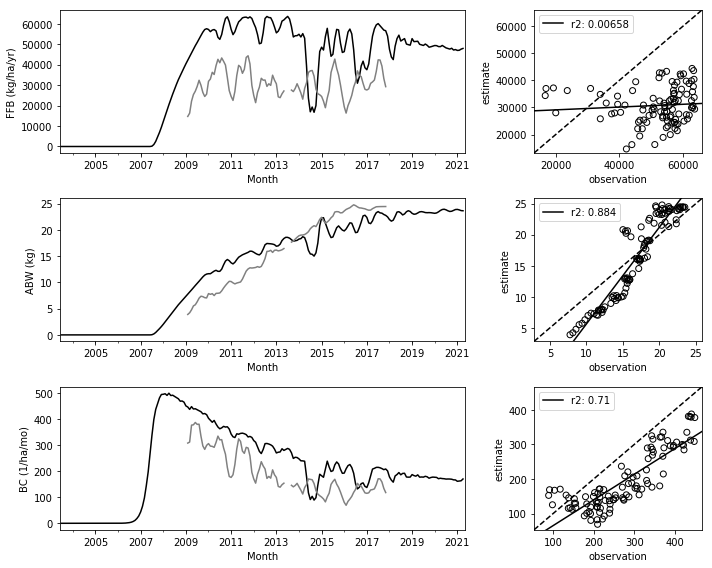

In [13]:
sname = 'A06b'

make_overview(df, dfo, sname, window=3)

r**2:  0.03570128307285303
r**2:  0.9117312162045998
r**2:  0.8159929349750397
Saving as: A06b.png


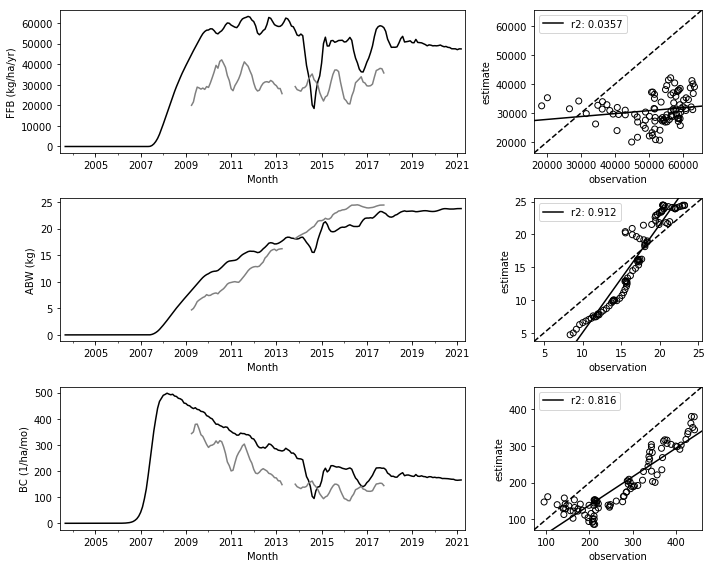

In [14]:
make_overview(df, dfo, sname, window=6)